In [12]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np

In [2]:
game_data = pd.read_csv("data/processed/steam_games.csv")
game_data.columns
game_data.head()
print(list(game_data.columns))

['appid', 'name', 'isfree', 'releasedate', 'releasedateprecision', 'releasedateraw', 'comingsoon', 'developers', 'publishers', 'genres', 'tags', 'controllersupport', 'players', 'players24h', 'players7d', 'playerstrend', 'playerschange24h', 'playerschange7d', 'playersrank', 'playersrankchange24h', 'avg30d', 'peak30d', 'peak30dat', 'low30d', 'low30dat', 'hoursplayed30d', 'peakalltime', 'peakalltimeat', 'last30days', 'last48h', 'playersupdatedat', 'metricsupdatedat', 'samplinginterval', 'playersstatus', 'hoursplayed30destimated', 'recommendations', 'metacritic', 'achievementscount', 'dlccount', 'requiredage', 'image', 'lastmodified', 'pricechangenumber', 'priceupdatedat', 'reviewsupdatedat', 'updatedat', 'prices.AU.country', 'prices.AU.currency', 'prices.AU.initial', 'prices.AU.final', 'prices.AU.discountpercent', 'prices.AU.formatted', 'prices.AU.convertedusd', 'prices.AU.onsale', 'prices.BR.country', 'prices.BR.currency', 'prices.BR.initial', 'prices.BR.final', 'prices.BR.discountpercen

In [3]:
# the most successful games by overall number of players
# it looks like players data is from the moment we queried the API, at least when it comes to players
successful_games = game_data.nlargest(10, 'players')
successful_games
# Print just the name and players columns
print(successful_games[['name', 'players']])

                                        name   players
21                          Counter-Strike 2  742806.0
18                                    Dota 2  526771.0
12506                    PUBG: BATTLEGROUNDS  122014.0
2013                                    Rust  113634.0
15                           Team Fortress 2   74554.0
5135          Tom Clancy's Rainbow Six Siege   71310.0
2944   The Witcher 3: Wild Hunt — Remastered   65469.0
1608                                Warframe   52579.0
1113                         Project Zomboid   50596.0
7791                                  VRChat   46081.0


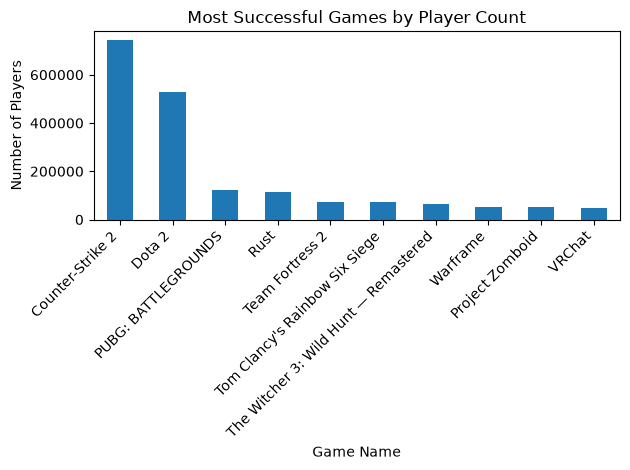

In [4]:
import matplotlib.pyplot as plt

# Create the bar chart
successful_games.plot.bar(x='name', y='players', rot=45, legend=False)

# Rotate by 45 degrees and align them properly under the bars
plt.xticks(rotation=45, ha='right')

# Add titles and labels
plt.title('Most Successful Games by Player Count')
plt.xlabel('Game Name')
plt.ylabel('Number of Players')

# Adjust layout so labels don't get cut off at the bottom
plt.tight_layout()

# Display the chart
plt.show()

In [5]:
# Most successful games by reviews
successful_games_by_reviews = game_data.nlargest(10, ['reviews.score', 'reviews.total'])
successful_games_by_reviews
# Print just the name and players columns
print(successful_games_by_reviews[['name', 'reviews.score', 'reviews.total']])

                                       name  reviews.score  reviews.total
1102                               Terraria              9        1558730
125                             Garry's Mod              9        1267733
17                            Left 4 Dead 2              9        1060484
7002                         Stardew Valley              9        1041491
1572                 Euro Truck Simulator 2              9         945785
2944  The Witcher 3: Wild Hunt — Remastered              9         897658
1796                             The Forest              9         683345
5440                          Hollow Knight              9         563383
1753                            Dying Light              9         496299
19                                 Portal 2              9         467376


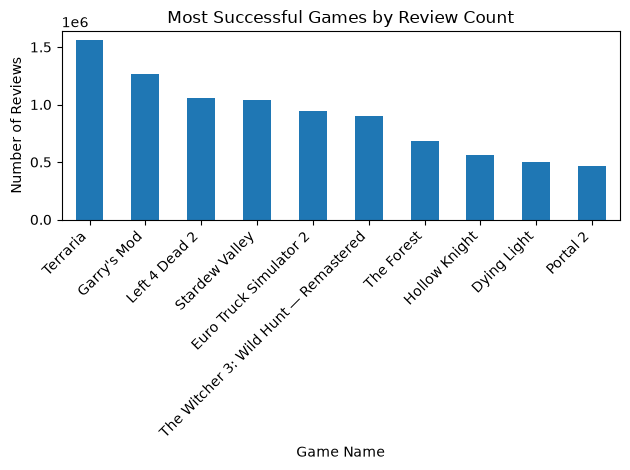

In [6]:
# Create the bar chart
successful_games_by_reviews.plot.bar(x='name', y='reviews.total', rot=45, legend=False)

# Rotate by 45 degrees and align them properly under the bars
plt.xticks(rotation=45, ha='right')

# Add titles and labels
plt.title('Most Successful Games by Review Count')
plt.xlabel('Game Name')
plt.ylabel('Number of Reviews')

# Adjust layout so labels don't get cut off at the bottom
plt.tight_layout()

# Display the chart
plt.show()

In [7]:
# the most successful games by overall number of players
# it looks like all the data is from the last 30 days, at least when it comes to players
successful_games = game_data.nlargest(10, 'peakalltime')
successful_games
# Print just the name and players columns
print(successful_games[['name', 'peakalltime']])

                      name  peakalltime
12506  PUBG: BATTLEGROUNDS    3236027.0
21        Counter-Strike 2    1818368.0
18                  Dota 2    1291328.0
1102              Terraria     486918.0
5790             Fallout 4     471955.0
10849    Life is Strange 2     468634.0
11623        HELLDIVERS™ 2     458208.0
1632                POSTAL     408008.0
11584    World of Warships     400538.0
5570            Kathy Rain     336132.0


In [8]:
# Main columns indicating player engagement
engagement_cols = [
    'avg30d',
    'peak30d',
    'players24h',
    'hoursplayed30d',
    'players',
    'peakalltime'
]

# Basic summary
game_data[engagement_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
avg30d,19374.0,189.501548,7.663314e+03,0.0,0.0,0.0,1.0,811711.0
peak30d,19374.0,368.133117,1.393993e+04,0.0,0.0,0.0,2.0,1452036.0
players24h,3384.0,1492.663416,2.691881e+04,0.0,3.0,11.0,59.0,1160588.0
hoursplayed30d,19374.0,136278.189068,5.517587e+06,0.0,0.0,0.0,493.0,584431920.0
players,19374.0,157.005471,6.818319e+03,0.0,0.0,0.0,0.0,742806.0
peakalltime,19374.0,1989.534428,3.138130e+04,0.0,0.0,0.0,176.0,3236027.0


In [28]:
zero_avg = game_data[game_data['avg30d'] == 0]

zero_avg[['name', 'avg30d', 'players24h', 'peak30d']].head(30)

# Compare player metrics for zero-average games
zero_avg[
    ['avg30d', 'players24h', 'peak30d', 'players', 'peakalltime']
].describe()

,avg30d,players24h,peak30d,players,peakalltime
count,13800.0,30.0,13800.000000,13800.0,13800.000000
mean,0.0,0.0,0.152899,0.0,154.381232
std,0.0,0.0,0.401225,0.0,2317.636229
min,0.0,0.0,0.000000,0.0,0.000000
25%,0.0,0.0,0.000000,0.0,0.000000
50%,0.0,0.0,0.000000,0.0,0.000000
75%,0.0,0.0,0.000000,0.0,0.000000
max,0.0,0.0,3.000000,0.0,180471.000000


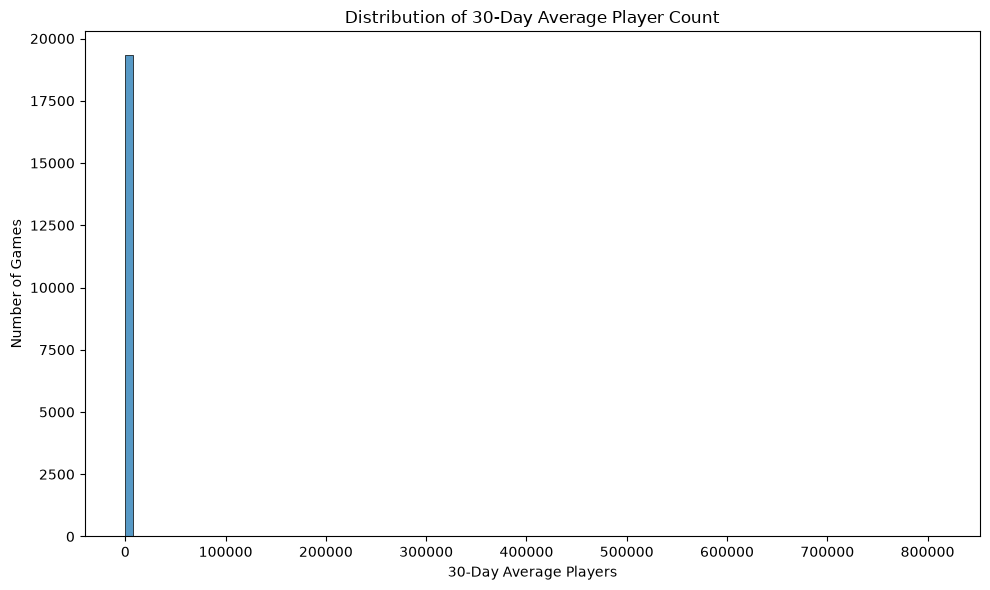

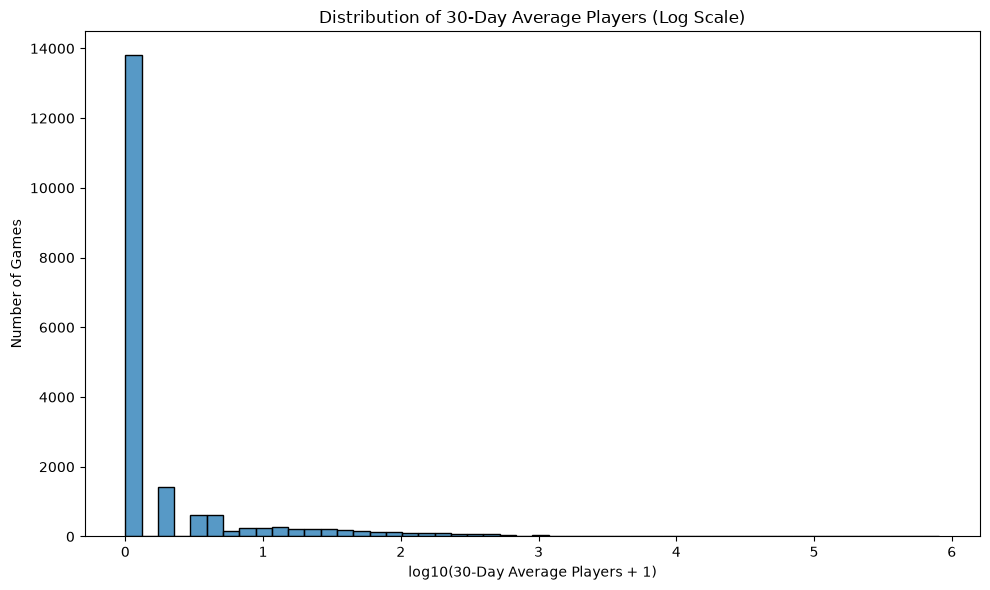

In [29]:
# Distribution of 30-day average player counts
plt.figure(figsize=(10, 6))

sns.histplot(
    data=game_data,
    x='avg30d',
    bins=100
)

plt.title('Distribution of 30-Day Average Player Count')
plt.xlabel('30-Day Average Players')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

# Above chart on a log scale because it's really bad
game_data['log_avg30d'] = np.log10(game_data['avg30d'] + 1)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=game_data,
    x='log_avg30d',
    bins=50
)

plt.title('Distribution of 30-Day Average Players (Log Scale)')
plt.xlabel('log10(30-Day Average Players + 1)')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

In [30]:
# How many games have at least one current player?
print("avg30d > 0:", (game_data['avg30d'] > 0).sum())

# How many have at least one player historically?
print("peakalltime > 0:", (game_data['peakalltime'] > 0).sum())

# How many have historical players but currently have zero?
historically_active_currently_zero = (
    (game_data['peakalltime'] > 0) &
    (game_data['avg30d'] == 0)
)

print(
    "Historical players but avg30d = 0:",
    historically_active_currently_zero.sum()
)

avg30d > 0: 5574
peakalltime > 0: 8888
Historical players but avg30d = 0: 3314


player_category
0                 13800
1–10               3298
11–100             1496
101–1,000           582
1,001–10,000        154
10,001–100,000       41
100,000+            629
Name: count, dtype: int64
player_category
0                 69.0
1–10              16.5
11–100             7.5
101–1,000          2.9
1,001–10,000       0.8
10,001–100,000     0.2
100,000+           3.1


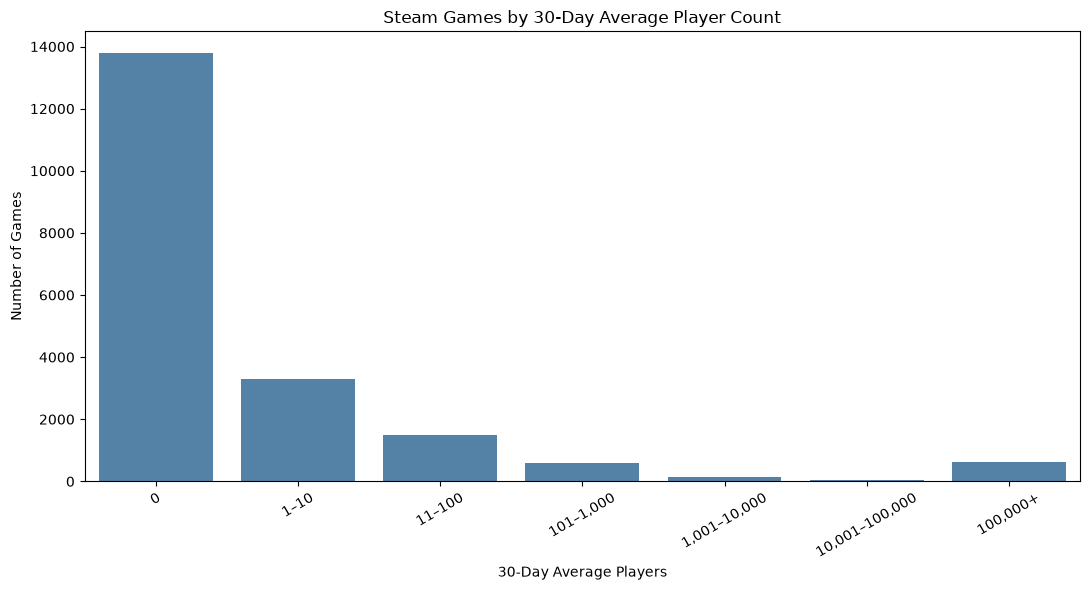

In [33]:
# Create meaningful player-count categories
def categorize_players(x):
    if x == 0:
        return '0'
    elif x <= 10:
        return '1–10'
    elif x <= 100:
        return '11–100'
    elif x <= 1000:
        return '101–1,000'
    elif x <= 10000:
        return '1,001–10,000'
    elif x <= 100000:
        return '10,001–100,000'
    else:
        return '100,000+'

game_data['player_category'] = (
    game_data['avg30d']
    .apply(categorize_players)
)

category_order = [
    '0',
    '1–10',
    '11–100',
    '101–1,000',
    '1,001–10,000',
    '10,001–100,000',
    '100,000+'
]

category_counts = (
    game_data['player_category']
    .value_counts()
    .reindex(category_order)
)

print(category_counts)

category_percentages = (
    category_counts / category_counts.sum() * 100
)

print(
    category_percentages.round(1).to_string()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    color='steelblue'
)

plt.title('Steam Games by 30-Day Average Player Count')
plt.xlabel('30-Day Average Players')
plt.ylabel('Number of Games')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [34]:
# Remove games where avg30d is missing
analysis_data = game_data.dropna(
    subset=['avg30d']
).copy()

# Calculate the 90th percentile
success_threshold = analysis_data['avg30d'].quantile(0.90)

print(
    f"90th percentile of average 30-day players: "
    f"{success_threshold:,.0f}"
)

# Define highly successful games
analysis_data['highly_successful'] = (
    analysis_data['avg30d'] >= success_threshold
)

print("\nNumber of highly successful games:")
print(
    analysis_data['highly_successful'].sum()
)

print("\nPercentage highly successful:")
print(
    analysis_data['highly_successful'].mean() * 100
)

90th percentile of average 30-day players: 16

Number of highly successful games:
1942

Percentage highly successful:
10.02374316093734


In [36]:
successful_games = (
    analysis_data[
        analysis_data['highly_successful']
    ]
    .sort_values('avg30d', ascending=False)
)

print(
    successful_games[
        ['name', 'avg30d', 'peak30d', 'peakalltime']
    ].head(30).to_string(index=False)
)

print(
    "Minimum avg30d among highly successful games:",
    successful_games['avg30d'].min()
)

print(
    "Maximum avg30d among highly successful games:",
    successful_games['avg30d'].max()
)

                                       name   avg30d   peak30d  peakalltime
                           Counter-Strike 2 811711.0 1452036.0    1818368.0
                                     Dota 2 574908.0  919002.0    1291328.0
                        PUBG: BATTLEGROUNDS 310923.0  788224.0    3236027.0
                                       Rust  83242.0  159010.0     259646.0
             Tom Clancy's Rainbow Six Siege  64298.0  120267.0     200476.0
                            Team Fortress 2  57205.0   90404.0     253225.0
                                   Warframe  55840.0  108836.0     181509.0
                            Project Zomboid  53429.0  100244.0     124506.0
              The Binding of Isaac: Rebirth  53111.0   92691.0     155966.0
                                War Thunder  52907.0  100117.0     125317.0
                             Stardew Valley  48769.0   92373.0     236614.0
                           Dead by Daylight  47079.0   75951.0     168845.0
            

In [37]:
# Checking what data has made it over here
candidate_variables = [
    'price',
    'positivepercent',
    'metacritic',
    'recommendations',
    'reviews.total',
    'reviews.score',
    'release_age',
    'isfree',
    'dlccount',
    'windows',
    'mac',
    'linux'
]

available_variables = [
    col for col in candidate_variables
    if col in analysis_data.columns
]

print(available_variables)

['metacritic', 'recommendations', 'reviews.total', 'reviews.score', 'isfree', 'dlccount']


In [39]:
# Comparing the games that we're considering successful using the above variables
comparison = (
    analysis_data
    .groupby('highly_successful')[available_variables]
    .median()
    .T
)

comparison.columns = [
    'Other Games',
    'Highly Successful'
]

comparison['Difference'] = (
    comparison['Highly Successful']
    - comparison['Other Games']
)

comparison


,Other Games,Highly Successful,Difference
metacritic,71.0,79.0,8.0
recommendations,337.0,7255.0,6918.0
reviews.total,84.0,8929.5,8845.5
reviews.score,6.0,8.0,2.0
isfree,0.0,0.0,0.0
dlccount,0.0,1.0,1.0
